## Example program to process actiGraph data

In [1]:
""" This script provides an example pipeline for predicting Physical Behaviour
(PB) and Energy Expenditure (EE) from actiGraph wearable sensor data.

It supports both:
    - Compressed gt3x files (.gt3x)

The script loads the data, applies a trained machine learning model, and
outputs window-based predictions for PB and EE.
This example is intended for research and demonstration purposes within
the WEALTH project framework.
"""

' This script provides an example pipeline for predicting Physical Behaviour\n(PB) and Energy Expenditure (EE) from actiGraph wearable sensor data.\n\nIt supports both:\n    - Compressed gt3x files (.gt3x)\n\nThe script loads the data, applies a trained machine learning model, and\noutputs window-based predictions for PB and EE.\nThis example is intended for research and demonstration purposes within\nthe WEALTH project framework.\n'

## Install the wealth_pb_ee_models package


In [2]:
import importlib.util
import glob, os

PKG = "wealth_pb_ee_models"
REPO = "wealth_pb_ee_models"
URL = "https://github.com/luisfrancs/wealth_pb_ee_models.git"

if importlib.util.find_spec(PKG) is None:
    if not os.path.isdir(REPO):
        !git clone {URL}
    %cd {REPO}
    %pip install -e . --config-settings editable_mode=compat
    %cd ..
else:
    print("Package already installed.")

Package already installed.


## Import functions and libraries

In [3]:
from wealth_pb_ee_models.models.pretrained_models import multi_taks_7classes_AG
from wealth_pb_ee_models.utils.utils import predict_single_file_AG
import matplotlib.pyplot as plt
import pandas as pd
from importlib.resources import files
import re, gc
from pathlib import Path

## LOAD KERAS MODEL


In [4]:
loaded_model, encoding_dict_PB, encoding_dict_EE =multi_taks_7classes_AG()

Metal device set to: Apple M1


2026-02-09 16:04:36.456634: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-09 16:04:36.456740: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
encoding_dict_PB

{0: 'Sitting',
 1: 'Standing',
 2: 'Walking',
 3: 'Running',
 4: 'Sports',
 5: 'Cycling',
 6: 'Lying'}

In [6]:
encoding_dict_EE

{0: 'Sedentary', 1: 'LPA', 2: 'MVPA'}

# SINGLE FILE PREDICTION

In [7]:
# Get path to sample_data folder
file_name="Test_DATA_AG/1221_testdata.gt3x"

In [10]:
#Predic PB and EE (it can load activPAL files: .datx (compressed) files and uncompresed .csv files)
df_predicted, accel_data = predict_single_file_AG(
    file_name, #Path to activPAL data file
    loaded_model, #Load trained model
    encoding_dict_PB, #Load Dictionnary for PB
    encoding_dict_EE) #Load Dictionnary for EE

2026-02-09 16:05:31.198823: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2026-02-09 16:05:31.281619: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


152/152 [==============================] - 5s 29ms/step


In [11]:
df_predicted

,Time,activity,Energy_expenditure
0,2023-08-14 15:00:00,Lying,Sedentary
1,2023-08-14 15:00:10,Lying,Sedentary
2,2023-08-14 15:00:20,Lying,Sedentary
3,2023-08-14 15:00:30,Lying,Sedentary
4,2023-08-14 15:00:40,Lying,Sedentary
...,...,...,...
77754,2023-08-23 14:59:00,Lying,Sedentary
77755,2023-08-23 14:59:10,Lying,Sedentary
77756,2023-08-23 14:59:20,Lying,Sedentary
77757,2023-08-23 14:59:30,Lying,Sedentary


## Daily spend time in different physical behaviours

In [12]:
#Import "wealth_pb_ee_models" utilities
from wealth_pb_ee_models.utils.utils_analytics import minutes_summary

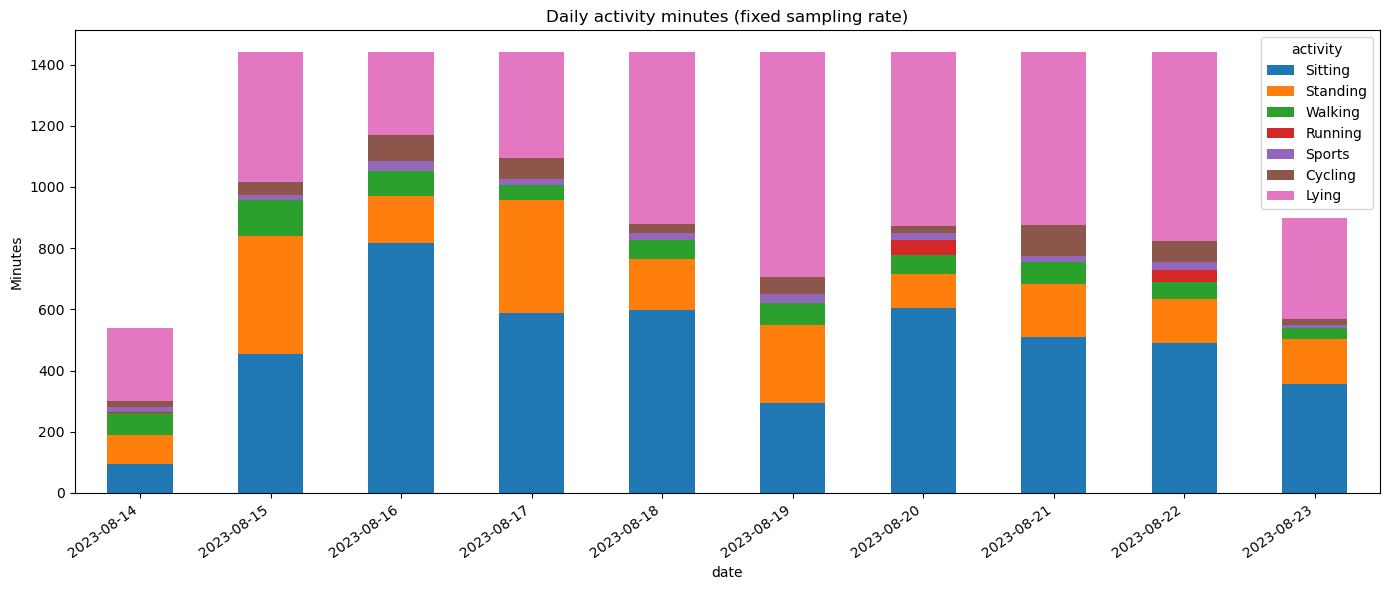

In [13]:
ACTIVITY_ORDER = ['Sitting', 'Standing', 'Walking', 'Running', 'Sports', 'Cycling','Lying']
minutes=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER, analytics="activity", plot=True)

In [14]:
minutes = minutes.round(2)
minutes

,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count
0,2023-08-14,93.33,97.67,70.67,1.67,19.00,17.33,240.33,540.00
1,2023-08-15,452.83,386.67,119.50,0.00,15.67,42.00,423.33,1440.00
2,2023-08-16,816.33,155.33,81.50,0.33,31.17,85.00,270.33,1440.00
3,2023-08-17,587.67,368.17,52.00,0.00,18.83,68.00,345.33,1440.00
4,2023-08-18,597.00,167.17,62.00,0.17,22.00,30.50,561.17,1440.00
5,2023-08-19,293.50,255.17,71.83,1.67,28.33,55.00,734.50,1440.00
6,2023-08-20,606.00,108.33,63.00,50.67,21.67,22.17,568.17,1440.00
7,2023-08-21,509.33,174.50,69.83,0.33,21.33,101.83,562.83,1440.00
8,2023-08-22,488.83,145.67,53.83,39.50,27.17,66.83,618.17,1440.00
9,2023-08-23,357.33,145.17,36.67,0.00,8.50,20.83,331.33,899.83


## Daily spend time in different levels of energy expenditure

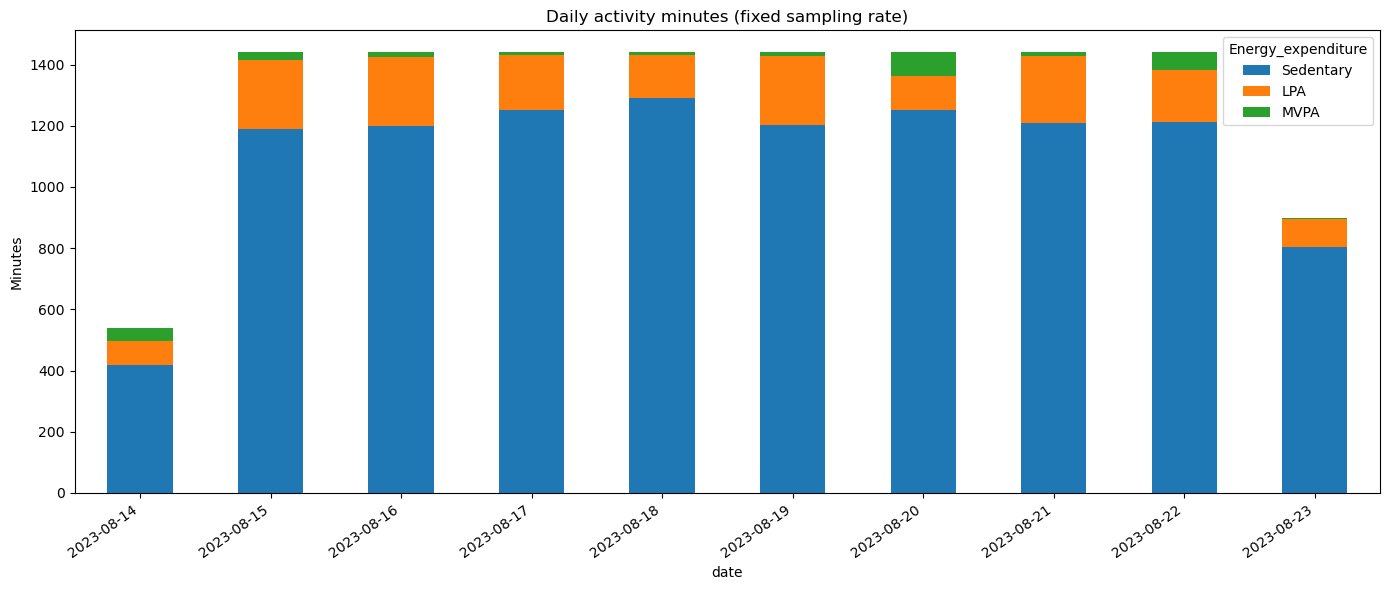

In [15]:
ACTIVITY_ORDER_EE = ['Sedentary', 'LPA', 'MVPA']
minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=True)

In [16]:
minutes_EE

,date,Sedentary,LPA,MVPA,daily_count
0,2023-08-14,417.500000,79.000000,43.500000,540.000000
1,2023-08-15,1190.000000,224.833333,25.166667,1440.000000
2,2023-08-16,1199.000000,226.333333,14.666667,1440.000000
3,2023-08-17,1250.333333,179.833333,9.833333,1440.000000
4,2023-08-18,1290.166667,141.000000,8.833333,1440.000000
5,2023-08-19,1202.666667,226.000000,11.333333,1440.000000
6,2023-08-20,1250.666667,110.666667,78.666667,1440.000000
7,2023-08-21,1210.666667,217.000000,12.333333,1440.000000
8,2023-08-22,1213.166667,170.500000,56.333333,1440.000000
9,2023-08-23,804.833333,90.500000,4.500000,899.833333


# BATCH PROCESSING

## Batch Prediction


In [17]:
# Step 1 – Predic PB and EE in all files stored in an specific folder

path_AP_files ="Test_DATA_AG" # Folder of activePAL files (.datx or .csv)
out = Path("Predicted_AG_CSVs")
out.mkdir(exist_ok=True)
allFiles = glob.glob(path_AP_files + "/*.gt3x") #Filter files with specific extension

for file_ in allFiles:
    print(file_)
    df_predicted, _ = predict_single_file_AG(file_, loaded_model,encoding_dict_PB,encoding_dict_EE,batch_size=512)
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    # Save as CSV
    df_predicted.to_csv(out / f"{ID_num}_PB_EE_predicted_7class_multitask_AP.csv", index=False)
    del df_predicted
    gc.collect()#Clear memory

Test_DATA_AG/1221_testdata.gt3x
152/152 [==============================] - 4s 28ms/step


## Compute daily spend time in PB and EE as batch process

In [18]:
# Step 2 – Compute daily spend time in PB and EE and merges the resuults in a single dataframe

path =r'Predicted_AG_CSVs' # Folder of Predicted_AP_CSVs
allFiles = glob.glob(path + "/*.csv") #Filter files with specific extension
dfs = [] #Create an empty space to store the single files results

for file_ in allFiles:
    print(file_)
    df_predicted = pd.read_csv(file_, sep=",")
    ID_num = re.search(r'\d+', os.path.basename(file_)).group(0)#get ID number
    minutes_PB=minutes_summary(df_predicted,encoding_dict_PB,ACTIVITY_ORDER,analytics="activity",plot=False)
    minutes_EE=minutes_summary(df_predicted,encoding_dict_EE,ACTIVITY_ORDER_EE, analytics="Energy_expenditure", plot=False)
    minutes_EE = minutes_EE.drop(columns=["daily_count", "date"])#remove repeated columns
    minutes_df = pd.concat([minutes_PB, minutes_EE], axis=1)
    # Insert subject ID in the first column
    minutes_df.insert(0, "ID", ID_num)
    dfs.append(minutes_df)#store partial results
    
df_all = pd.concat(dfs, ignore_index=True)#flatten all dfs in a single df

Predicted_AG_CSVs/1221_PB_EE_predicted_7class_multitask_AP.csv


In [19]:
df_all = df_all.round(2)
df_all.head(12)

,ID,date,Sitting,Standing,Walking,Running,Sports,Cycling,Lying,daily_count,Sedentary,LPA,MVPA
0,1221,2023-08-14,93.33,97.67,70.67,1.67,19.00,17.33,240.33,540.00,417.50,79.00,43.50
1,1221,2023-08-15,452.83,386.67,119.50,0.00,15.67,42.00,423.33,1440.00,1190.00,224.83,25.17
2,1221,2023-08-16,816.33,155.33,81.50,0.33,31.17,85.00,270.33,1440.00,1199.00,226.33,14.67
3,1221,2023-08-17,587.67,368.17,52.00,0.00,18.83,68.00,345.33,1440.00,1250.33,179.83,9.83
4,1221,2023-08-18,597.00,167.17,62.00,0.17,22.00,30.50,561.17,1440.00,1290.17,141.00,8.83
5,1221,2023-08-19,293.50,255.17,71.83,1.67,28.33,55.00,734.50,1440.00,1202.67,226.00,11.33
6,1221,2023-08-20,606.00,108.33,63.00,50.67,21.67,22.17,568.17,1440.00,1250.67,110.67,78.67
7,1221,2023-08-21,509.33,174.50,69.83,0.33,21.33,101.83,562.83,1440.00,1210.67,217.00,12.33
8,1221,2023-08-22,488.83,145.67,53.83,39.50,27.17,66.83,618.17,1440.00,1213.17,170.50,56.33
9,1221,2023-08-23,357.33,145.17,36.67,0.00,8.50,20.83,331.33,899.83,804.83,90.50,4.50


In [20]:
# SAVE TABLE DAILY SUMMARY PER SUBJECT
#df_all.to_csv("DAILY_SUMMARY_PER_SUBJECT_TEST.csv", index=False)

## Data analytics on multiple files

In [21]:
from wealth_pb_ee_models.utils.utils_analytics import filter_valid_days,summarize_weekday_weekend_weighted, summarize_weekday_weekend
from wealth_pb_ee_models.utils.utils_analytics import plot_multiple_weighted_summaries, prepare_plot_data, plot_activity_bars

In [22]:
# Step 1 – Filter valid days per hour (≥ 8 hours)
df_valid = filter_valid_days(df_all, min_wear_hours=8)

In [27]:
# Step 2 – Summarise weekday vs weekend in a single value (WEIGTHED 2/5)
'''Summarise activity per participant using a weighted average. Weighting: Weekdays: 5/7; Weekends: 2/7'''
summary_weigthed_AG = summarize_weekday_weekend_weighted(df_valid,ACTIVITY_ORDER,ACTIVITY_ORDER_EE)
summary_weigthed_AG

,ID,Sitting_mean,Sitting_std,Standing_mean,Standing_std,Walking_mean,Walking_std,Running_mean,Running_std,Sports_mean,...,Cycling_mean,Cycling_std,Lying_mean,Lying_std,Sedentary_mean,Sedentary_std,LPA_mean,LPA_std,MVPA_mean,MVPA_std
0,1221,476.950893,212.024282,198.388393,107.480835,68.011429,19.526081,11.227143,19.792456,21.75625,...,49.624286,28.81415,485.454643,137.368778,1116.161964,227.083392,166.755536,64.956243,28.496429,26.90165


In [29]:
summary_weigthed_AG

,ID,Sitting_mean,Sitting_std,Standing_mean,Standing_std,Walking_mean,Walking_std,Running_mean,Running_std,Sports_mean,...,Cycling_mean,Cycling_std,Lying_mean,Lying_std,Sedentary_mean,Sedentary_std,LPA_mean,LPA_std,MVPA_mean,MVPA_std
0,1221,476.950893,212.024282,198.388393,107.480835,68.011429,19.526081,11.227143,19.792456,21.75625,...,49.624286,28.81415,485.454643,137.368778,1116.161964,227.083392,166.755536,64.956243,28.496429,26.90165
1,1221,476.950893,212.024282,198.388393,107.480835,68.011429,19.526081,11.227143,19.792456,21.75625,...,49.624286,28.81415,485.454643,137.368778,1116.161964,227.083392,166.755536,64.956243,28.496429,26.90165


## Averaged daily distribution of time spent in PB (Weighted summaries) 

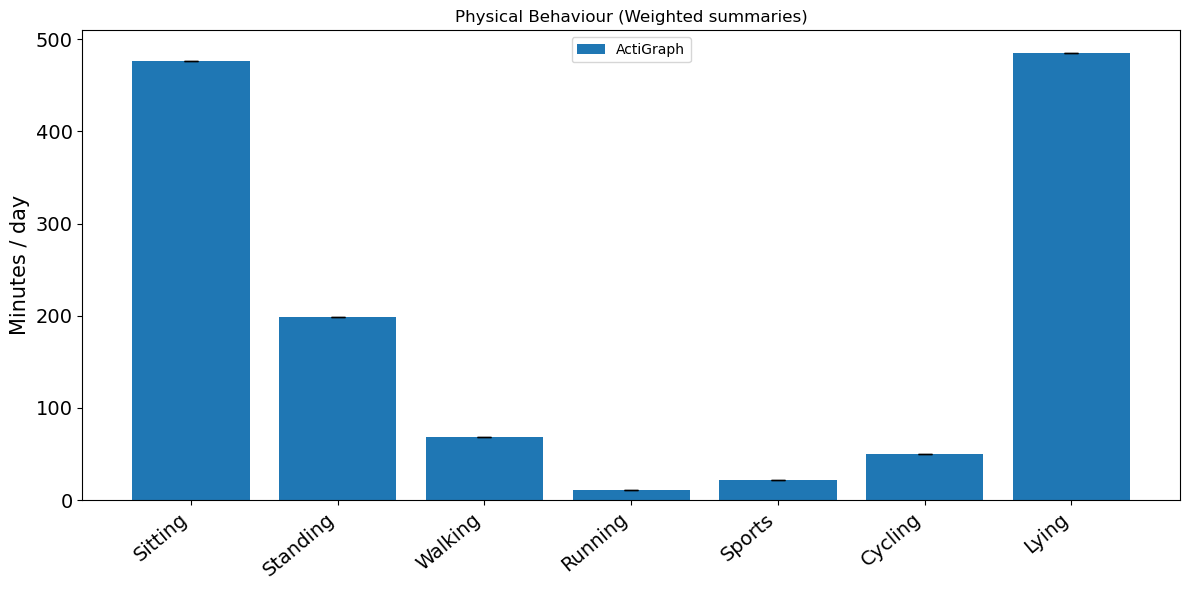

In [30]:
plot_multiple_weighted_summaries(
    summaries={ "ActiGraph":summary_weigthed_AG},
    variables=ACTIVITY_ORDER, title="Physical Behaviour (Weighted summaries)")

## Averaged daily distribution of time spent in EE (Weighted summaries) 

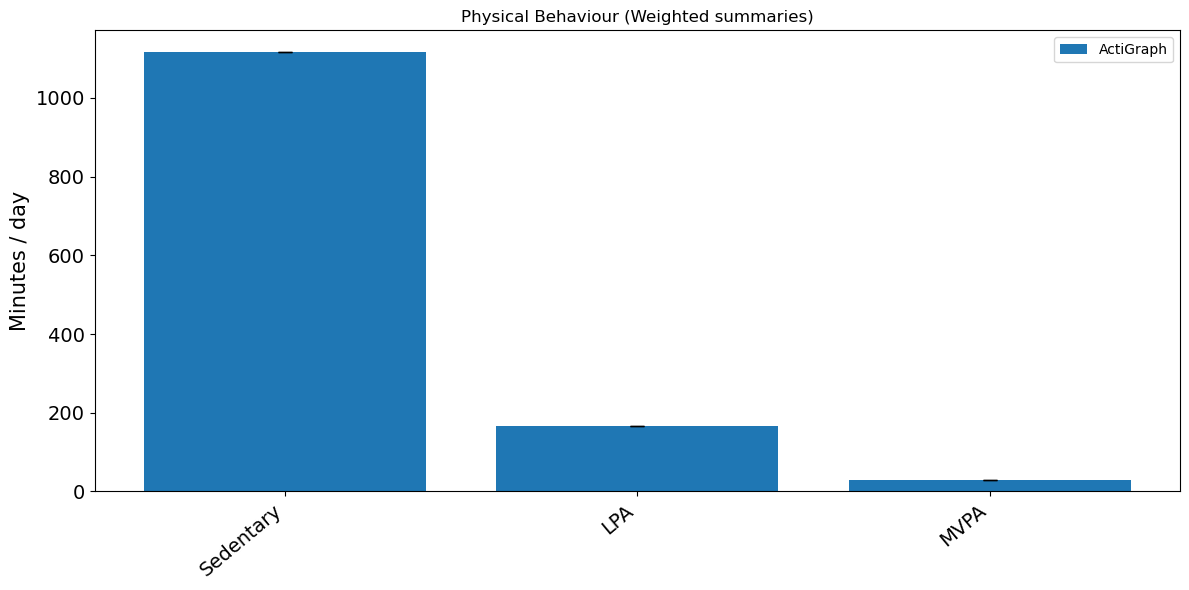

In [33]:
plot_multiple_weighted_summaries(
    summaries={ "ActiGraph":summary_weigthed_AG },
    variables=ACTIVITY_ORDER_EE, title="Physical Behaviour (Weighted summaries)")